<a href="https://colab.research.google.com/github/AytenHarman07/AytenHarman07/blob/main/Proteomics_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

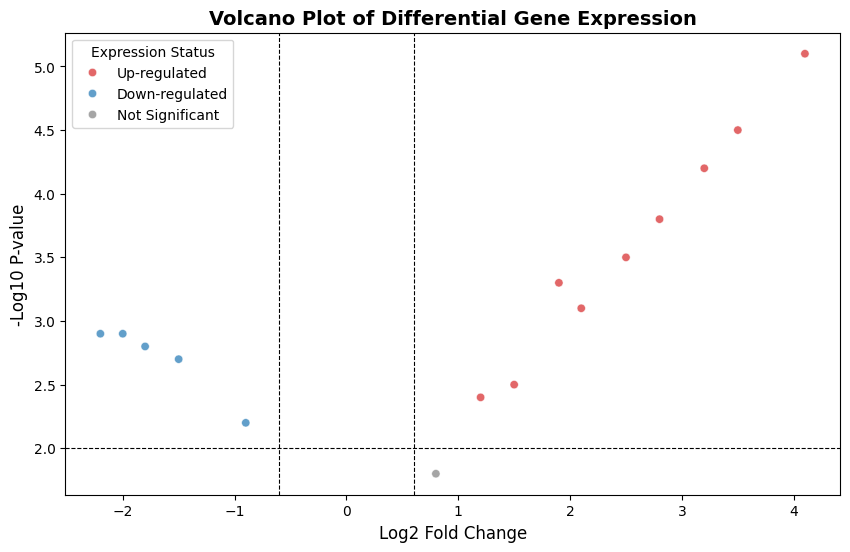

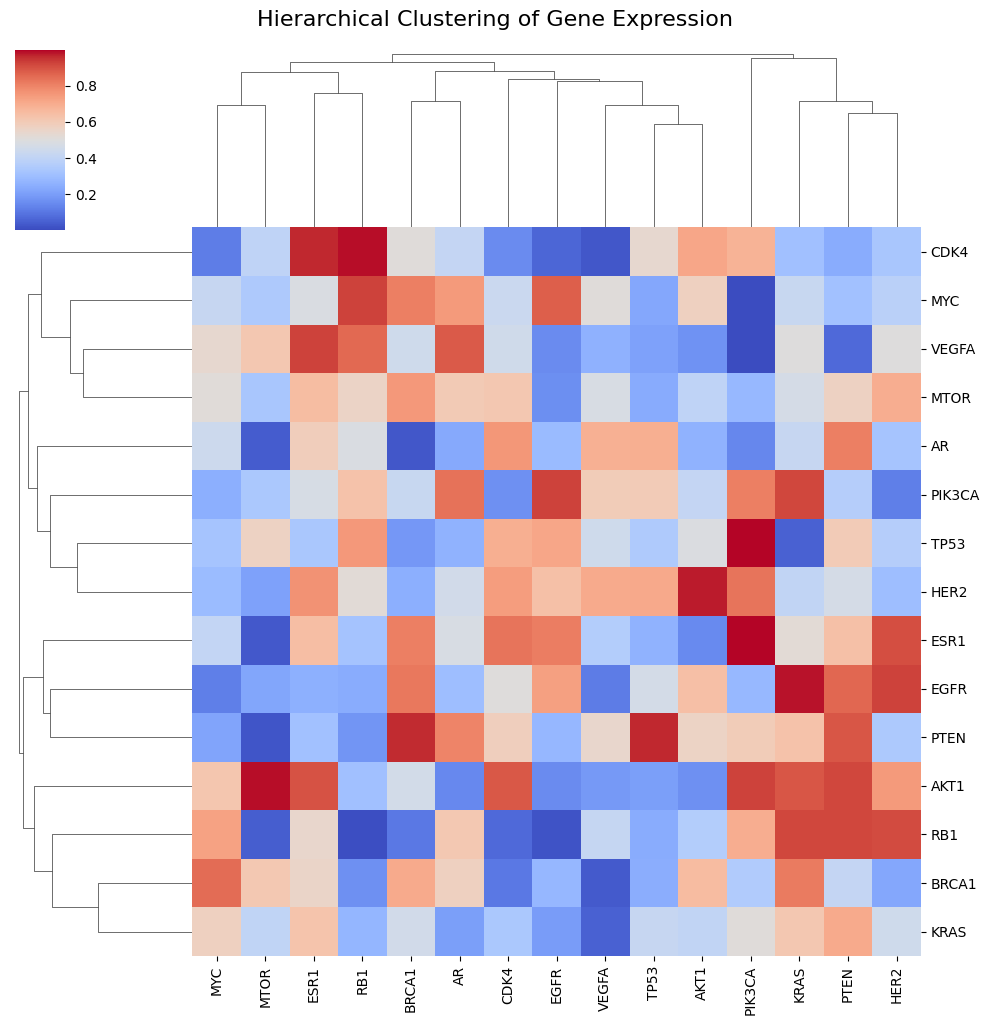

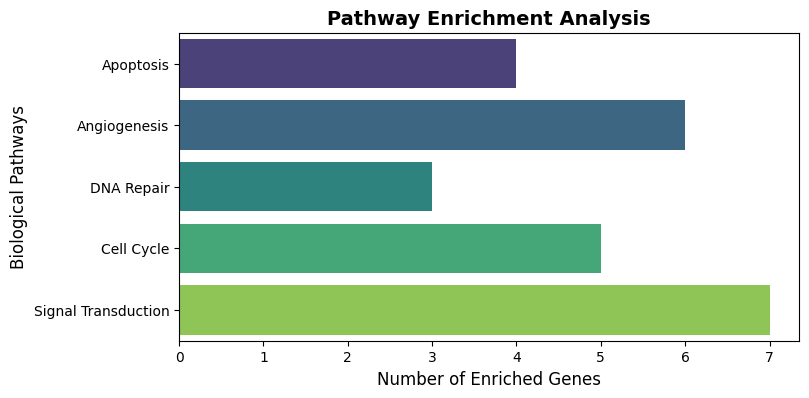

In [2]:
# --- 1. KÜTÜPHANELER VE VERİ HAZIRLIĞI ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Gen seti ile verimizi oluşturalım
gene_names = ['BRCA1', 'TP53', 'EGFR', 'MYC', 'PTEN', 'HER2', 'KRAS', 'ESR1', 'AR', 'VEGFA', 'CDK4', 'PIK3CA', 'MTOR', 'AKT1', 'RB1']
data = {
    'Gene_Name': gene_names,
    'Log2_FC': [2.5, -1.8, 3.2, 4.1, -2.2, 2.8, 1.5, -0.9, 1.2, 3.5, 0.8, 2.1, -1.5, 1.9, -2.0],
    'Log10_P': [3.5, 2.8, 4.2, 5.1, 2.9, 3.8, 2.5, 2.2, 2.4, 4.5, 1.8, 3.1, 2.7, 3.3, 2.9]
}
df = pd.DataFrame(data)

# Sınıflandırma
def classify(row):
    if row['Log10_P'] > 2 and row['Log2_FC'] > 0.6: return 'Up-regulated'
    elif row['Log10_P'] > 2 and row['Log2_FC'] < -0.6: return 'Down-regulated'
    else: return 'Not Significant'

df['Status'] = df.apply(classify, axis=1)

# --- 2. VOLCANO PLOT ---
plt.figure(figsize=(10, 6))
palette = {'Up-regulated': '#d62728', 'Down-regulated': '#1f77b4', 'Not Significant': '#7f7f7f'}
sns.scatterplot(data=df, x='Log2_FC', y='Log10_P', hue='Status', palette=palette, alpha=0.7)
plt.title("Volcano Plot of Differential Gene Expression", fontsize=14, fontweight='bold')
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-value", fontsize=12)
plt.axhline(y=2, color='black', linestyle='--', linewidth=0.8)
plt.axvline(x=0.6, color='black', linestyle='--', linewidth=0.8)
plt.axvline(x=-0.6, color='black', linestyle='--', linewidth=0.8)
plt.legend(title='Expression Status')
plt.show()

# --- 3. CLUSTERMAP (ISI HARİTASI) ---
# Korelasyon matrisi simülasyonu
corr_matrix = pd.DataFrame(np.random.rand(15, 15), columns=gene_names, index=gene_names)
g = sns.clustermap(corr_matrix, cmap='coolwarm', figsize=(10, 10))
g.fig.suptitle('Hierarchical Clustering of Gene Expression', fontsize=16, y=1.02)
plt.show()

# --- 4. PATHWAY ENRICHMENT (BAR CHART) ---
pathway_data = pd.DataFrame({
    'Pathway': ['Apoptosis', 'Angiogenesis', 'DNA Repair', 'Cell Cycle', 'Signal Transduction'],
    'Gene_Count': [4, 6, 3, 5, 7]
})

plt.figure(figsize=(8, 4))
sns.barplot(data=pathway_data, x='Gene_Count', y='Pathway', palette='viridis',hue='Pathway', legend=False)
plt.title("Pathway Enrichment Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Number of Enriched Genes", fontsize=12)
plt.ylabel("Biological Pathways", fontsize=12)
plt.show()